In [47]:
import pandas as pd

data = pd.read_csv(r"C:\Users\USER\Desktop\資訊所實習\計畫\Gene list\consensus_results.Alphaviridae.txt",sep="\t")

In [49]:
data.columns

Index(['Gene', 'RF_mean_abs_Score', 'XGB_mean_abs_Score',
       'RF_median_abs_Score', 'XGB_median_abs_Score', 'RF_Rank_byMean',
       'XGB_Rank_byMean', 'RF_Rank_byMedian', 'XGB_Rank_byMedian',
       'Avg_Rank_byMean', 'Avg_Rank_byMedian'],
      dtype='object')

In [50]:
# 先將RF_mean_abs_Score取出來，當作enrichment的ranking

rf_rank = data[["Gene","RF_mean_abs_Score"]]

print(rf_rank.head())

     Gene  RF_mean_abs_Score
0   PANK4           0.001713
1    XAB2           0.001408
2  ANAPC2           0.000821
3  P2RY11           0.000929
4    ZASP           0.001024


In [51]:
# 很多基因的數值為0

rf_rank = rf_rank.loc[rf_rank["RF_mean_abs_Score"] != 0,:]

In [52]:
rf_rank.columns = ["gene", "score"]

print(rf_rank.head())

     gene     score
0   PANK4  0.001713
1    XAB2  0.001408
2  ANAPC2  0.000821
3  P2RY11  0.000929
4    ZASP  0.001024


In [53]:
rf_gene_list = rf_rank["gene"].tolist()
len(rf_gene_list)

6206

In [30]:
import gseapy as gp


res = gp.enrichr(
    gene_list=rf_gene_list,
    gene_sets="KEGG_2021_Human"
)

In [54]:
print(res.results.head(10))

          Gene_set                                               Term Overlap  \
0  KEGG_2021_Human                 Mannose type O-glycan biosynthesis   10/23   
1  KEGG_2021_Human                                Sulfur relay system     4/8   
2  KEGG_2021_Human                         Inflammatory bowel disease   23/65   
3  KEGG_2021_Human                                        Ferroptosis   15/41   
4  KEGG_2021_Human                                Caffeine metabolism     3/6   
5  KEGG_2021_Human                                         Alcoholism  61/186   
6  KEGG_2021_Human                       Systemic lupus erythematosus  44/135   
7  KEGG_2021_Human                                Allograft rejection   13/38   
8  KEGG_2021_Human  PD-L1 expression and PD-1 checkpoint pathway i...   29/89   
9  KEGG_2021_Human                               Salmonella infection  79/249   

    P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  0.143716          0.99999

In [35]:
res_2 = gp.prerank(
    rnk=rf_rank,
    gene_sets="KEGG_2021_Human",
    permutation_num=1000,
    seed=123
)

In [56]:
import pandas as pd

gsea_table = pd.DataFrame(res_2.res2d)

In [57]:
print(gsea_table.head())

      Name                                              Term        ES  \
0  prerank  Inflammatory mediator regulation of TRP channels  0.818059   
1  prerank                    Glycerophospholipid metabolism  0.798970   
2  prerank                                     Thermogenesis  0.779149   
3  prerank           Neutrophil extracellular trap formation  0.773373   
4  prerank                      Systemic lupus erythematosus  0.766627   

        NES  NOM p-val  FDR q-val  FWER p-val  Tag %  Gene %  \
0  1.389827   0.049345        1.0       0.805   3/16   2.40%   
1  1.364416   0.046138        1.0       0.896   5/21   8.22%   
2  1.354057   0.013000        1.0       0.931   6/44   2.40%   
3  1.353239   0.011000        1.0       0.934  25/49  13.79%   
4  1.340634   0.018000        1.0       0.959  22/44  13.79%   

                                          Lead_genes  
0                                PLA2G6;ASIC3;MAPK11  
1                      PLA2G6;PEMT;LCAT;PNPLA7;CDIPT  
2    

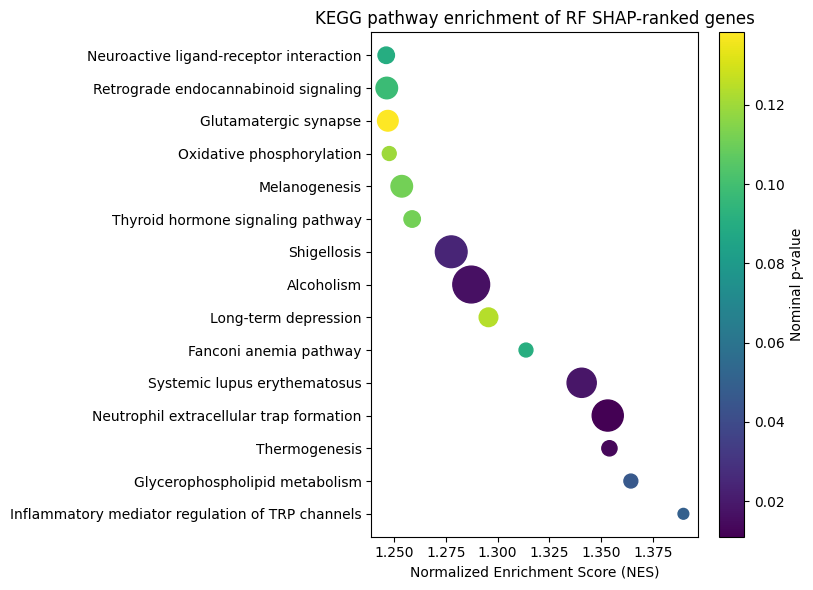

In [67]:
import matplotlib.pyplot as plt


plot_df = gsea_table.head(15).copy()


plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["NES"],
    plot_df["Term"],
    s=plot_df["Tag %"].str.split("/").str[0].astype(int)*20,
    c=plot_df["NOM p-val"],
    cmap="viridis"
)

plt.xlabel("Normalized Enrichment Score (NES)")
plt.ylabel("")
plt.title("KEGG pathway enrichment of RF SHAP-ranked genes")

plt.colorbar(label="Nominal p-value")

plt.tight_layout()
plt.show()

In [68]:
len(gsea_table)

168

In [59]:
gsea_df = res_2.res2d.copy()

top20 = (
    gsea_df
    .sort_values("NES", ascending=False)
    .head(20)
)

In [64]:
network_df = []

for _, row in top20.iterrows():

    pathway = row["Term"]

    genes = row["Lead_genes"].split(";")

    for gene in genes:

        network_df.append(
            [pathway, gene]
        )


top5 = (
    gsea_df
    .sort_values("NES", ascending=False)
    .head(5)
)

network_df = pd.DataFrame(
    network_df,
    columns=["Pathway","Gene"]
)

network_df = network_df[
    network_df["Pathway"].isin(
        top5["Term"]
    )
]

import networkx as nx


G = nx.Graph()


for _, row in network_df.iterrows():

    G.add_edge(
        row["Pathway"],
        row["Gene"]
    )

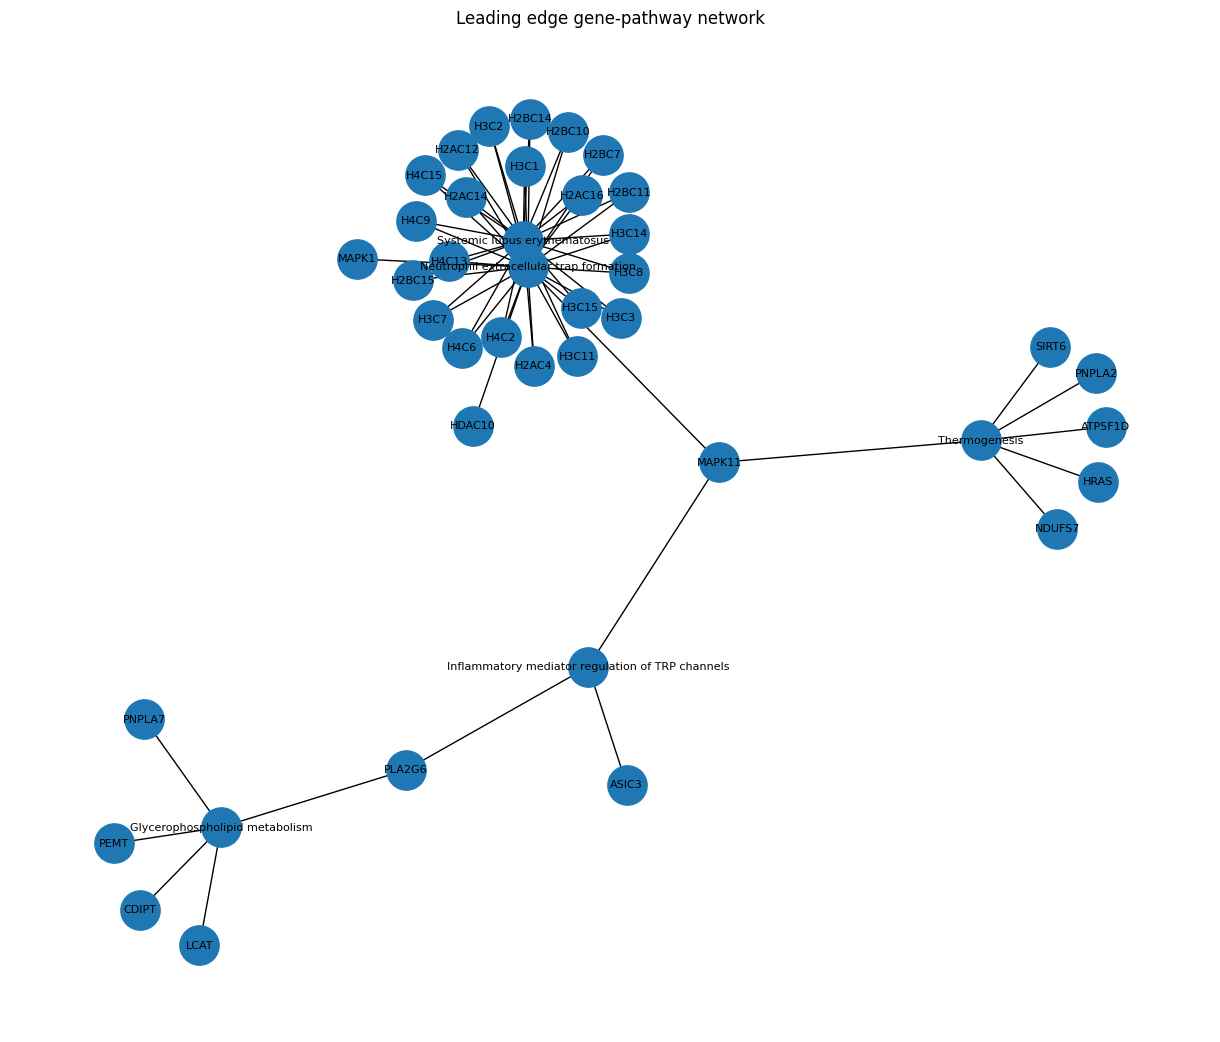

In [65]:
plt.figure(figsize=(12,10))


pos = nx.spring_layout(
    G,
    seed=123
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=800,
    font_size=8
)


plt.title(
    "Leading edge gene-pathway network"
)

plt.show()